## Weather data

Most crop simulations require weather input data. Most commonly:
    - Solar irradiance (MJ/m2/day)
    - Precipation (mm/month)
    
And less important
    - Days with rain (1/month)
    
This demo comes with weather data files which can be found in the inputs folder.
    
**Note, these input files can for instance be opened/altered in Excel.**

In [1]:
# import pandas --- spreadsheet library
import pandas as pd

# import matplotlib --- plotting library
import matplotlib.pyplot as plt 

In [2]:
import os

fpath = '../../data/agrifood/KBD - 2006.xlsx'
dfo = pd.read_excel(fpath)

fpath = '../../data/agrifood/KBL - 2006 - weather.xlsx'
dfw = pd.read_excel(fpath)

In [3]:
import sys
sys.path.append('../PalmSim')
sys.path.append('..')
from palmsim import PalmField

# 1. Initialize the model
p = PalmField(year_of_planting=2003, month_of_planting= 6)

# 2. Couple the solar radiation data:
p.weather.radiation_series = dfw['Irradiation (MJ/m2/d)'].resample('D').pad()

s = dfw['Precipitation (mm/month)'].resample('D').pad()
s = s/s.index.days_in_month

p.weather.rainfall_series = s

#p.weather.rainfall_series = s

In [4]:
tw0, tw1 = dfw.index[0], dfw.index[-1]
tw0, tw1

(Timestamp('2006-01-01 00:00:00'), Timestamp('2017-12-01 00:00:00'))

In [5]:
import time
import tqdm

In [6]:
t0 = time.time()

dt = 3

p.dt = dt

nyears = 30

duration = nyears*365
nsteps = duration//dt

res = {}

for i in tqdm.tqdm(range(nsteps)):
    
    p.update(dt=dt)
    
    res[i] = p.to_dict()
    
t1 = time.time()

print(t1 - t0)

100%|██████████████████████████████████████| 3650/3650 [01:07<00:00, 54.33it/s]


67.19160580635071


In [7]:
import pandas as pd

df = pd.DataFrame(res).T

In [8]:
df = df.set_index(pd.to_datetime(df['date']))

13149.0
2006-01-01 00:00:00


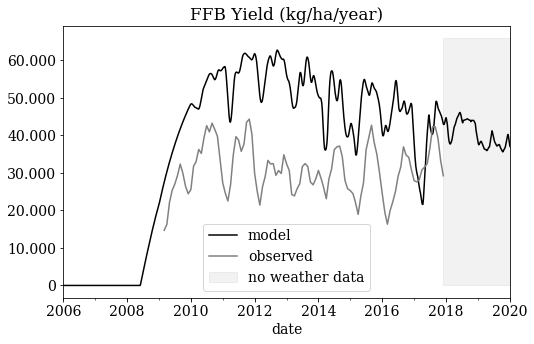

In [46]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 14

fig, ax = plt.subplots(figsize=(8,5))

df['generative_FFB_production (t/ha/yr)'].plot(ax=ax,color='black',ls='solid', label='model')

(12*1000*dfo['Y (t/ha/mo)']).rolling(3,center=True).mean().plot(ax=ax, color='grey', label='observed')

ax.set_xlim('2006','2020')

t0, t1 = ax.get_xlim()

print(t0)
print(tw0)

y0, y1 = ax.get_ylim()

ax.fill_between([t0,tw0],0, y1)
ax.fill_between([tw1,t1],0, y1, color='grey', alpha=0.1, label='no weather data')

ax.set_yticklabels(["{:,}".format(int(y)).replace(',','.') for y in ax.get_yticks()])

ax.set_title('FFB Yield (kg/ha/year)')

ax.legend()

plt.savefig('out.png', dpi=300)

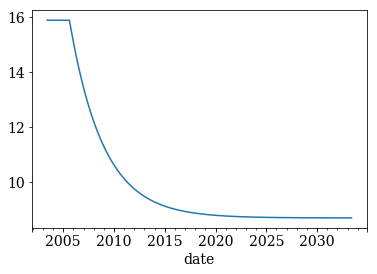

In [42]:
df['fronds_count_growth_rate (1/ha/day)'].plot()

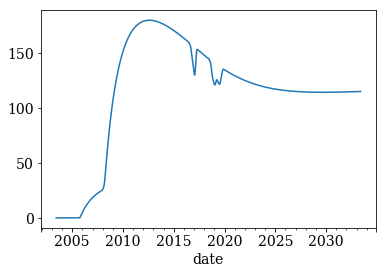

In [43]:
df['generative_potential_sink_strength (kg_CH2O/ha/day)'].plot()

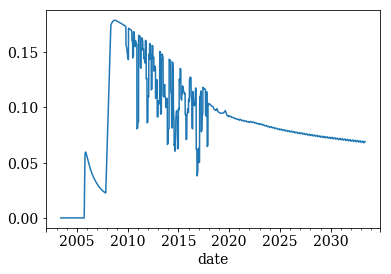

In [44]:
df['generative_Ic (1)'].plot()

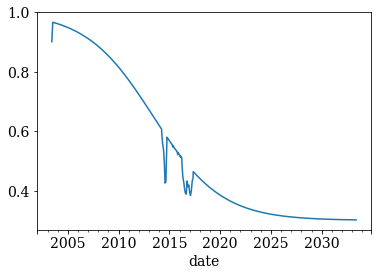

In [45]:
df['generative_female_fraction (1)'].plot()

(13149, 18262)

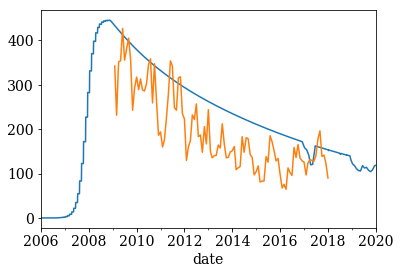

In [14]:
((365/12)*df['generative_bunch_count (1/ha/day)']).plot()
ax = (dfo['BC (1/ha/mo)']).plot()
ax.set_xlim('2006','2020')

(13149, 18262)

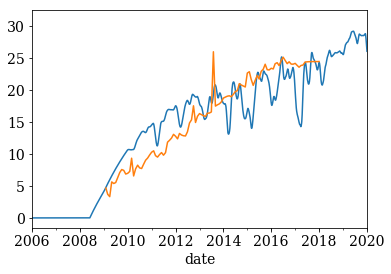

In [15]:
(2*df['generative_bunch_weight (kg_DM)']).plot()
ax = dfo['ABW (kg)'].plot()
ax.set_xlim('2006','2020')

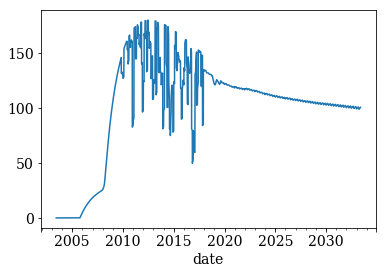

In [16]:
df['assimilates_assim_growth_generative (kg_CH2O/ha/day)'].plot()

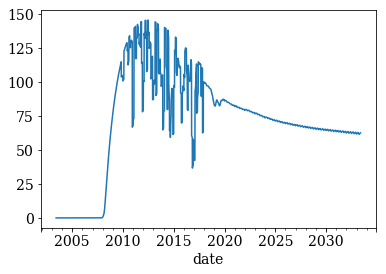

In [17]:
df['generative_assim_growth_females (kg_CH2O/ha/day)'].plot()

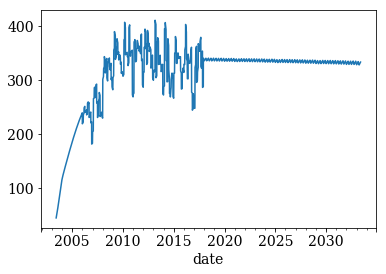

In [18]:
df['assimilates_assim_produced (kg_CH2O/ha/day)'].plot()

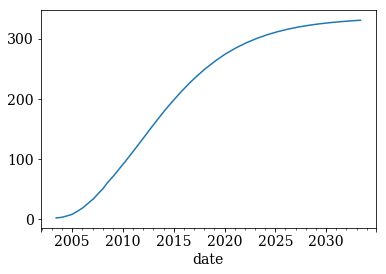

In [19]:
df['trunk_mass_per_palm (kg_DM/palm)'].plot()

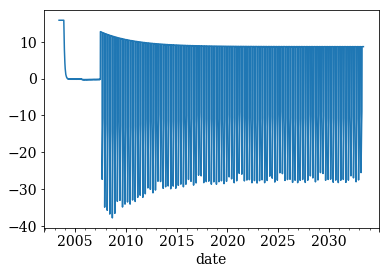

In [20]:
df['fronds_count_change_rate (1/ha/day)'].plot()

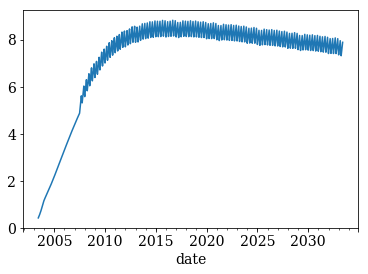

In [21]:
df['fronds_leaf_area_index (1)'].plot()

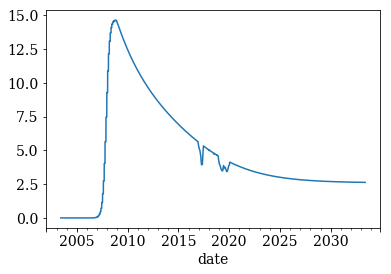

In [22]:
df['generative_bunch_count (1/ha/day)'].plot()

In [23]:
p.generative.cohorts[0]

Object: Female

Property                                     Value Unit        
--------------------------------------------------------------
Ic                                           0.000  1           
abortion_fraction                            0.000  1           
age                                       1200.000  day         
assim_growth_cohort                          0.000  kg_CH2O/cohort/day
assim_growth_organ                           0.000  kg_CH2O/organ/day
bunch_failure_fraction                       0.000  1           
has_flowered                                 1.000  bool        
inflorescence_abortion_fraction              0.000  1           
is_deletable                                 0.000  bool        
is_harvestible                               1.000  bool        
maintenance_requirement                      0.033  kg_CH2O/organ/day
mass                                        15.118  kg_DM       
mass_growth_rate                             0.000  kg_DM/day

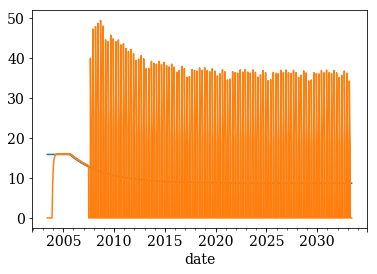

In [24]:
df['fronds_count_growth_rate (1/ha/day)'].plot()
df['fronds_count_loss_rate (1/ha/day)'].plot()

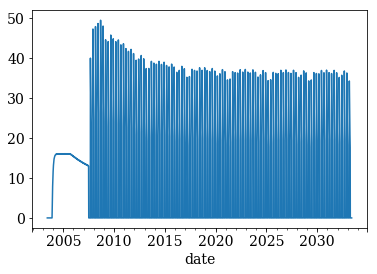

In [25]:
df['management_prune_rate (1/ha/day)'].plot()

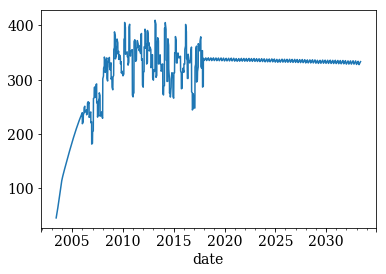

In [26]:
df['fronds_assim_produced (kg_CH2O/ha/day)'].plot()

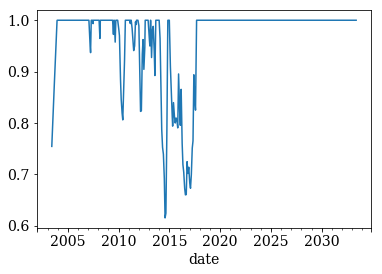

In [27]:
df['soil_moisture_content (1)'].plot()

In [28]:
p.weather

Object: Weather

Property                                     Value Unit        
--------------------------------------------------------------
PAR                                          8.625  MJ/m2/day   
radiation                                   17.250  MJ/m2/day   
radiation_series_mean                       17.250  MJ/m2/day   
raindays                                    14.000  1/mo        
raindays_series_mean                        14.000  1/mo        
rainfall                                     5.469  mm/day      
rainfall_series_mean                         5.469  mm/day      

In [29]:
p.date_tuple

(2033, 5, 24)

In [30]:
p.trunk.mass, p.trunk.mass_change_rate

(45621.72355975085, 0.38641285586917895)

In [31]:
p.roots.mass, p.roots.mass_change_rate

(22291.7736118915, 1.4485949558635127)

In [32]:
p.fronds.mass, p.fronds.mass_change_rate

(13335.503374422877, 17.80174596930068)

In [33]:
p.assimilates.assim_produced, p.assimilates.assim_growth_total

(332.89317904261384, 145.80209917490697)

In [34]:
p.fronds

Object: Fronds

Property                                     Value Unit        
--------------------------------------------------------------
LUE                                          4.200  g_CH2O/MJ PAR
assim_growth                                25.800  kg_CH2O/ha/day
assim_produced                             333.173  kg_CH2O/ha/day
count                                     6502.728  1/ha        
count_change_rate                            8.698  1/ha/day    
count_growth_rate                            8.698  1/ha/day    
count_loss_rate                              0.000  1/ha/day    
count_per_palm                              47.121  1/palm      
fraction_intercepted                         0.926  1           
initiation_rate                              0.063  1/palm/day  
intercepted_PAR                             79.861  GJ/ha/day   
leaf_area_index                              7.887  1           
leaf_area_per_palm                         571.552  m2          
mainten

In [35]:
p.generative

Object: Cohorts

Property                                     Value Unit        
--------------------------------------------------------------
CPO_production                              15.811  kg_DM/ha/day
EFB_production                              21.992  kg_DM/ha/day
FFB_production                           29036.150  t/ha/yr     
Ic                                           0.069  1           
PKO_production                               1.972  kg_DM/ha/day
assim_growth                               100.745  kg_DM/ha/day
assim_growth_females                        62.556  kg_CH2O/ha/day
assim_growth_indeterminates                 38.189  kg_CH2O/ha/day
assim_growth_males                           0.000  kg_CH2O/ha/day
bunch_count                                  2.631  1/ha/day    
bunch_failure_fraction                       0.000  1           
bunch_production                            39.776  kg_DM/ha/day
bunch_weight                                15.118  kg_DM       
bunch

In [36]:
p.soil.available_water, p.soil.available_water_change_rate,

(400.0, -6.217248937900877e-15)

In [37]:
p.assimilates

Object: Assimilates

Property                                     Value Unit        
--------------------------------------------------------------
assim_growth_fronds                         25.800  kg_CH2O/ha/day
assim_growth_generative                    100.745  kg_CH2O/ha/day
assim_growth_roots                          18.697  kg_CH2O/ha/day
assim_growth_total                         145.802  kg_CH2O/ha/day
assim_growth_trunk                           0.560  kg_CH2O/ha/day
assim_growth_vegetative                     45.057  kg_CH2O/ha/day
assim_maintenance_fronds                    47.484  kg_CH2O/ha/day
assim_maintenance_generative                67.765  kg_CH2O/ha/day
assim_maintenance_roots                     49.032  kg_CH2O/ha/day
assim_maintenance_total                    187.091  kg_CH2O/ha/day
assim_maintenance_trunk                     22.810  kg_CH2O/ha/day
assim_maintenance_vegetative               119.326  kg_CH2O/ha/day
assim_produced                             332.8

In [38]:
cohort = p.generative.cohorts[0]

In [39]:
cohort

Object: Female

Property                                     Value Unit        
--------------------------------------------------------------
Ic                                           0.000  1           
abortion_fraction                            0.000  1           
age                                       1200.000  day         
assim_growth_cohort                          0.000  kg_CH2O/cohort/day
assim_growth_organ                           0.000  kg_CH2O/organ/day
bunch_failure_fraction                       0.000  1           
has_flowered                                 1.000  bool        
inflorescence_abortion_fraction              0.000  1           
is_deletable                                 0.000  bool        
is_harvestible                               1.000  bool        
maintenance_requirement                      0.033  kg_CH2O/organ/day
mass                                        15.118  kg_DM       
mass_growth_rate                             0.000  kg_DM/day